## 02 探索性資料分析
#### 專案主題：青少年性別與身高之顯著差異分析 (YRBS 2007)
本筆記本將讀取清洗好的數據，計算分組描述統計量（平均數、標準差），並利用視覺化圖表直觀地觀察兩性身高分佈的趨勢。

#### 描述性統計觀察
* **樣本大小**：男高中生 **$6,572$ 筆**，女高中生 **$6,490$ 筆**。樣本量極大，抽樣誤差非常小。
* **平均身高差異**：男高中生平均身高為 **$1.7574$ 公尺**，女高中生為 **$1.6299$ 公尺**。男高中生平均比女高中生高出 **$0.1275$ 公尺（即 12.75 公分）**。
* **標準差**：男生的身高標準差 ($0.0838$) 略大於女生 ($0.0738$)，顯示男生的身高離散程度與個體差異稍高。

## 02 Exploratory Data Analysis (EDA)
#### Project Topic: Significant Difference Analysis of Gender and Height in Adolescents (YRBS 2007)
This notebook reads the cleaned and processed dataset to compute group-specific descriptive statistics, including sample sizes ($n$), means, and standard deviations. Furthermore, it utilizes statistical visualizations to intuitively observe and compare the distribution trends of height between male and female students.

#### Descriptive Statistics Observations
* **Sample Size**: There are **$6,572$ 筆** observations for male students and **$6,490$ 筆** observations for female students. The exceptionally large sample size minimizes sampling error.
* **Mean Height Difference**: The mean height is **$1.7574$ 公尺** meters for male students and **$1.6299$ 公尺** meters for female students. On average, male students are **$0.1275$  meters (approximately 12.75 cm) taller than female students.
* **Standard Deviation (SD)**: The standard deviation for males ($0.0838$) is slightly larger than that for females ($0.0738$), indicating a marginally higher degree of dispersion and individual variability in male height.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 設定學術繪圖風格
sns.set_theme(style="whitegrid")
%matplotlib inline

print("啟動階段二：探索性資料分析...")

# 讀取步驟一產出的乾淨資料 
processed_paths = ['data/processed/cleaned_height_data.csv', 'cleaned_height_data.csv']
processed_path = next((p for p in processed_paths if os.path.exists(p)), None)

if processed_path:
    df_eda = pd.read_csv(processed_path)
    print(f"成功載入乾淨數據，有效樣本: {len(df_eda)} 筆")
else:
    raise FileNotFoundError("找不到乾淨的數據檔！請確保先執行了 01_data_preprocessing.ipynb 產生資料。")

啟動階段二：探索性資料分析...
成功載入乾淨數據，有效樣本: 13062 筆


In [6]:
summary_table = df_eda.groupby('Gender_Label')['Height'].agg(['count', 'mean', 'std'])
summary_table.columns = ['Sample Size (n)', 'Mean Height (m)', 'Std Deviation (m)']
print("==========================================")
print("       DESCRIPTIVE STATISTICS SUMMARY")
print("==========================================")
display(summary_table.round(4))
print("==========================================")

       DESCRIPTIVE STATISTICS SUMMARY


,Sample Size (n),Mean Height (m),Std Deviation (m)
Gender_Label,,,
Female,6490,1.6299,0.0738
Male,6572,1.7574,0.0838


箱型圖已儲存至: outputs\height_boxplot.png


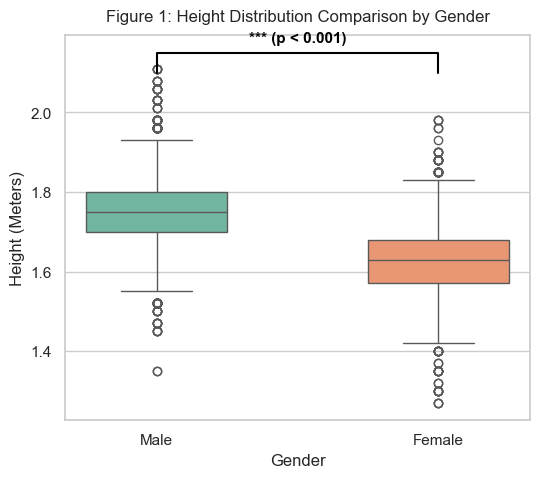

In [28]:
# 確保 outputs 資料夾存在 (移除 ../)
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

# 繪製 箱型圖
plt.figure(figsize=(6, 5))
sns.boxplot(
    x="Gender_Label",
    y="Height",
    data=df_eda,
    hue="Gender_Label",
    palette="Set2",
    legend=False,
    width=0.5,
)
plt.title(
    "Figure 1: Height Distribution Comparison by Gender", fontsize=12, pad=10
)
plt.xlabel("Gender")
plt.ylabel("Height (Meters)")

# ✨ 新增：自動畫出倒 ㄈ 字型的統計顯著性對比線
# 1. 畫出水平橫線與兩端的垂直短線 (x座標：0是Male, 1是Female；y座標：控制在 2.10 到 2.15 公尺高)
plt.plot([0, 0, 1, 1], [2.10, 2.15, 2.15, 2.10], color="black", linewidth=1.5)

# 2. 在對比線的正中央加上 *** 標記與 p 值
plt.text(
    0.5,
    2.17,
    "*** (p < 0.001)",
    ha="center",
    va="bottom",
    color="black",
    fontsize=11,
    fontweight="bold",
)

# 儲存圖片
boxplot_path = os.path.join(output_dir, "height_boxplot.png")
plt.savefig(boxplot_path, dpi=300, bbox_inches="tight")
print(f"箱型圖已儲存至: {boxplot_path}")
plt.show()

#### 箱型圖觀察
* **分佈落差與重疊度**：Figure 1 中的箱型圖清楚顯示，男高中生身高的箱體（代表中間 50% 數據的四分位距 IQR）整體顯著高於女生，且兩組身高的 IQR 區間幾乎沒有任何重疊。
* **顯著性視覺化**：圖上標記的對比水平線 $p < 0.001\ (***)$ 提示了後續假設檢定的高度顯著性結論。

#### Boxplot Observations
* **Distribution Shift and Overlap**: The boxplot in Figure 1 clearly illustrates that the box for male students (representing the Interquartile Range, IQR, or the middle 50% of the data) is positioned significantly higher than that for female students. Moreover, there is virtually no overlap between the IQR intervals of the two groups.
* **Visualizing Statistical Significance**: The horizontal contrast line marked with $p < 0.001\ (***)$ on the plot provides a strong visual indicator of the highly significant conclusion derived from the subsequent hypothesis test.

直方圖已儲存至: outputs\height_histogram.png


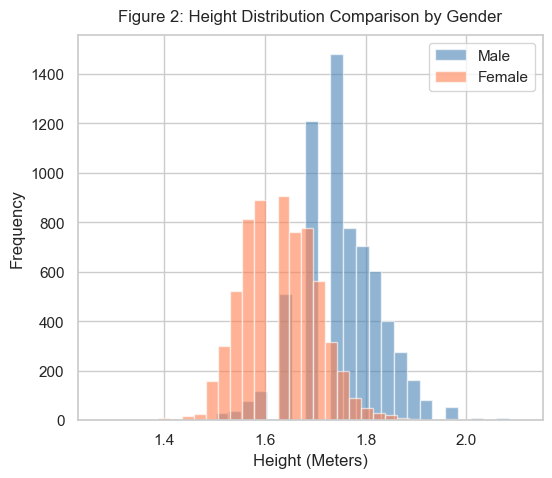

In [24]:
import os

# 💡 確保 outputs 資料夾存在
output_dir = 'outputs'
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(6, 5))
male_h = df_eda[df_eda['Gender_Label'] == 'Male']['Height']
female_h = df_eda[df_eda['Gender_Label'] == 'Female']['Height']

# 繪製 直方圖
plt.hist(male_h, alpha=0.6, label='Male', bins=30, color='steelblue', edgecolor='white')
plt.hist(female_h, alpha=0.6, label='Female', bins=30, color='coral', edgecolor='white')

plt.title('Figure 2: Height Distribution Comparison by Gender', fontsize=12, pad=10)
plt.xlabel('Height (Meters)')
plt.ylabel('Frequency')
plt.legend()

# 儲存圖片
hist_path = os.path.join(output_dir, 'height_histogram.png')
plt.savefig(hist_path, dpi=300, bbox_inches='tight')
print(f"直方圖已儲存至: {hist_path}")
plt.show()

#### 直方圖觀察 
* **常態性檢核**：Figure 2 顯示男女生的身高數據分佈皆呈現非常對稱、單峰且無明顯偏態的「鐘形分佈（Bell-shaped Distribution）」。這完美符合了雙樣本 T 檢定對數據必須符合常態分佈的前提假設要求。
* **分佈位移直觀化**：代表男生的藍色直方圖與代表女生的橘色直方圖主體，在橫軸（身高公尺）上呈現非常清晰的平行位移（男生主體偏右、女生主體偏左），這直觀地印證了兩組之間存在顯著的均值落差。

#### Histogram Observations
* **Normality Check**: Figure 2 demonstrates that the height distributions for both male and female students are highly symmetric, unimodal, and exhibit no severe skewness, resembling a classic "bell-shaped distribution." This perfectly satisfies the underlying normality assumption required for a two-sample t-test.
* **Visualizing Distribution Shift**: The blue histogram (representing males) and the coral histogram (representing females) display a very distinct parallel shift along the horizontal axis (height in meters), with the male distribution shifted to the right and the female distribution to the left. This provides an intuitive visual validation of the significant difference between the two group means.